# 01 – Univariate Analyse

Explorative Analyse der Solarproduktion und der meteorologischen Einflussgrossen.

## 1) Setup

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from IPython.display import display

from src.data.preprocessing import load_processed_data, load_pv_data
from src.features.feature_engineering import add_time_features

TARGET = "Solarproduktion"
P_NOM = 13_500.0   # installed capacity in W (= 13.5 kWp)
PERCENTILE = 10

plt.rcParams.update({"figure.dpi": 120, "axes.grid": True, "grid.alpha": 0.3})

df = load_processed_data("../data/processed/merged.csv")

def add_time_features(ldf: pd.DataFrame, timestamp_col: str = "timestamp") -> pd.DataFrame:
    """Add calendar/time features derived from the timestamp."""
    ldf = ldf.copy()
    ts = df[timestamp_col].dt

    ldf["hour"] = ts.hour
    ldf["day_of_week"] = ts.day_of_week
    ldf["month"] = ts.month
    ldf["is_weekend"] = (ts.day_of_week >= 5).astype(int)
    ldf["day_of_year"] = ts.day_of_year.astype(str)

    return ldf


df = add_time_features(df)

season_map = {
    12: "Winter", 1: "Winter", 2: "Winter",
    3: "Frühling", 4: "Frühling", 5: "Frühling",
    6: "Sommer",   7: "Sommer",   8: "Sommer",
    9: "Herbst",  10: "Herbst",  11: "Herbst",
}
df["season"] = df["month"].map(season_map)
season_order  = ["Winter", "Frühling", "Sommer", "Herbst"]
season_colors = {
    "Winter":   "#74b9ff",
    "Frühling": "#55efc4",
    "Sommer":   "#fdcb6e",
    "Herbst":   "#e17055",
}

print(f"Zeitraum: {df['timestamp'].min().date()} – {df['timestamp'].max().date()}")
print(f"Datenpunkte: {len(df):,}  (15-min-Auflösung)")


Zeitraum: 2022-02-07 – 2025-06-16
Datenpunkte: 117,620  (15-min-Auflösung)


## 2) Deskriptive Statistik

Drei Variablengruppen:
- **PV-Daten**: `Solarproduktion` [W]
- **Wetterdaten**: `temperature_2m` [°C], `cloud_cover_low` [%]
- **Einstrahlungsdaten**: `ghi_cloudy_sky`, `ghi_clear_sky` [W/m²]

In [2]:
print("PV-Daten:")
display(df[["Solarproduktion"]].describe().round(2))

print("\nWetterdaten:")
display(df[["temperature_2m", "cloud_cover_low"]].describe().round(2))

print("\nEinstrahlungsdaten:")
display(df[["ghi_cloudy_sky", "ghi_clear_sky"]].describe().round(2))


PV-Daten:


,Solarproduktion
count,117620.00
mean,363.22
std,652.77
min,0.00
25%,0.00
50%,2.00
75%,542.00
max,8668.00



Wetterdaten:


,temperature_2m,cloud_cover_low
count,117620.00,117620.00
mean,10.84,29.05
std,8.02,38.23
min,-13.50,0.00
25%,4.70,0.00
50%,10.40,6.00
75%,16.70,55.50
max,36.90,100.00



Einstrahlungsdaten:


,ghi_cloudy_sky,ghi_clear_sky
count,117620.00,117620.00
mean,43.95,50.18
std,63.87,68.58
min,0.00,0.00
25%,0.00,0.00
50%,0.98,1.36
75%,73.71,91.39
max,228.44,228.44


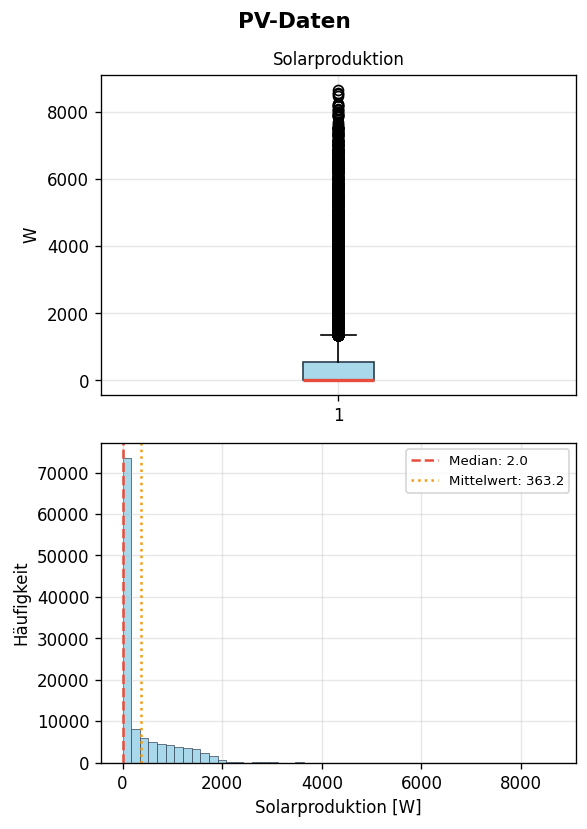

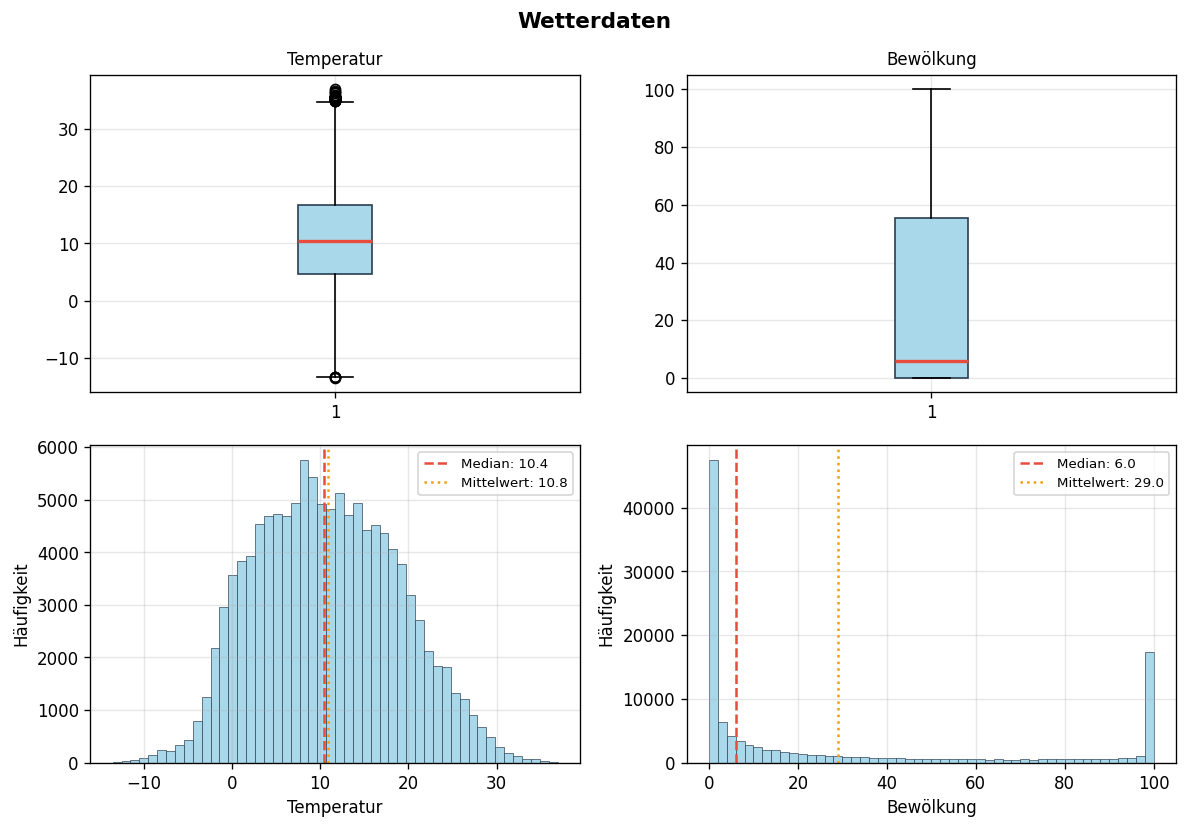

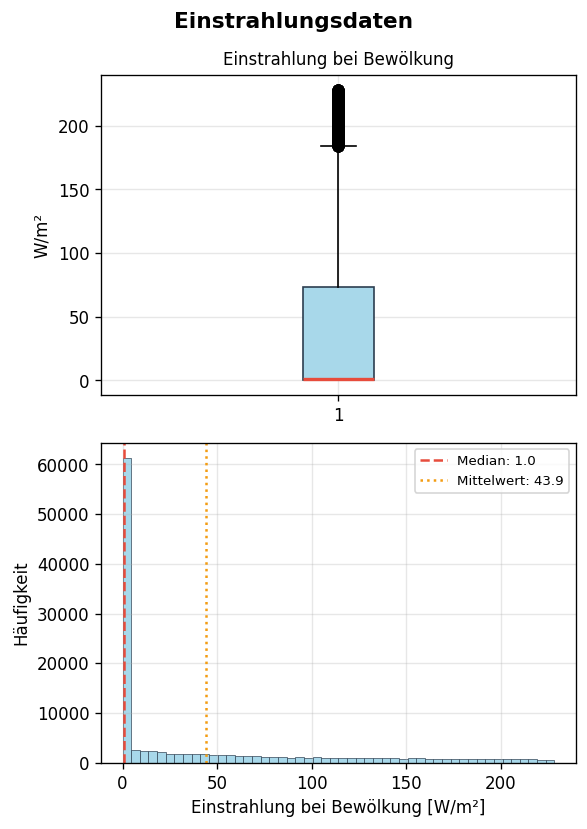

In [3]:
# Boxplots + Histogramme fur jede Variablengruppe

# Mapping für Anzeige-Namen (nur für Plots, DataFrame bleibt unverändert)
label_map = {
    "Solarproduktion": "Solarproduktion",
    "temperature_2m": "Temperatur",
    "cloud_cover_low": "Bewölkung",
    "ghi_cloudy_sky": "Einstrahlung bei Bewölkung"
}

groups = [
    (df[["Solarproduktion"]], "PV-Daten", "W"),
    (df[["temperature_2m", "cloud_cover_low"]], "Wetterdaten", ""),
    (df[["ghi_cloudy_sky"]], "Einstrahlungsdaten", "W/m²"),
]

for df_grp, title, unit in groups:
    cols = df_grp.columns.tolist()
    n = len(cols)
    fig, axes = plt.subplots(2, n, figsize=(5 * n, 7))
    
    if n == 1:
        axes = axes.reshape(2, 1)
        
    fig.suptitle(title, fontsize=13, fontweight="bold")

    for i, col in enumerate(cols):
        data = df_grp[col].dropna()

        # Anzeige-Name holen (fallback = originaler Name)
        display_name = label_map.get(col, col)

        label = f"{display_name}" + (f" [{unit}]" if unit else "")

        # Boxplot
        axes[0, i].boxplot(
            data,
            vert=True,
            patch_artist=True,
            boxprops=dict(facecolor="#a8d8ea", color="#2c3e50"),
            medianprops=dict(color="#e74c3c", linewidth=2)
        )
        axes[0, i].set_title(display_name, fontsize=10)
        axes[0, i].set_ylabel(unit if unit else "")

        # Histogramm
        axes[1, i].hist(
            data,
            bins=50,
            color="#a8d8ea",
            edgecolor="#2c3e50",
            linewidth=0.4
        )
        axes[1, i].axvline(
            data.median(),
            color="#e74c3c",
            linewidth=1.5,
            linestyle="--",
            label=f"Median: {data.median():.1f}"
        )
        axes[1, i].axvline(
            data.mean(),
            color="#f39c12",
            linewidth=1.5,
            linestyle=":",
            label=f"Mittelwert: {data.mean():.1f}"
        )
        axes[1, i].set_xlabel(label)
        axes[1, i].set_ylabel("Häufigkeit")
        axes[1, i].legend(fontsize=8)

    plt.tight_layout()
    plt.show()

## 3) Solarproduktion nach Stunde, Wochentag & Saison

### 3.1) Nach Stunde und Wochentag

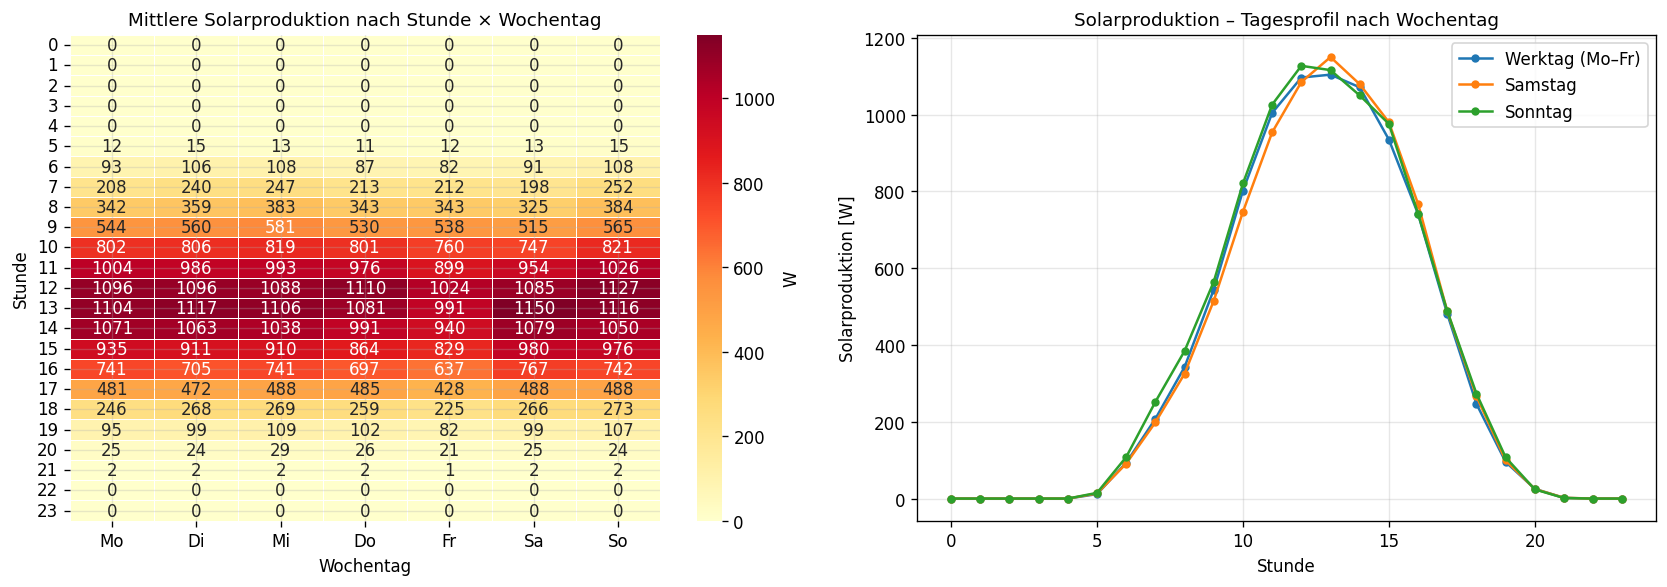

In [4]:
pv_hourly = (
    df.groupby(["day_of_week", "hour"])[TARGET]
    .mean()
    .reset_index(name="solarproduktion")
)

pivot = pv_hourly.pivot(index="hour", columns="day_of_week", values="solarproduktion")
pivot.columns = ["Mo", "Di", "Mi", "Do", "Fr", "Sa", "So"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(
    pivot,
    ax=axes[0],
    cmap="YlOrRd",
    annot=True,
    fmt=".0f",
    linewidths=0.4,
    cbar_kws={"label": "W"},
)
axes[0].set_title("Mittlere Solarproduktion nach Stunde × Wochentag", fontsize=11)
axes[0].set_xlabel("Wochentag")
axes[0].set_ylabel("Stunde")

for dow, name in [(0, "Werktag (Mo–Fr)"), (5, "Samstag"), (6, "Sonntag")]:
    sub = pv_hourly[pv_hourly["day_of_week"] == dow]
    axes[1].plot(sub["hour"], sub["solarproduktion"], marker="o", markersize=4, label=name)

axes[1].set_title("Solarproduktion – Tagesprofil nach Wochentag", fontsize=11)
axes[1].set_xlabel("Stunde")
axes[1].set_ylabel("Solarproduktion [W]")
axes[1].legend()

plt.tight_layout()
plt.show()


### 3.2) Nach Saison

C:\Users\Annika\AppData\Local\Temp\ipykernel_20408\2525447053.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[0].boxplot(


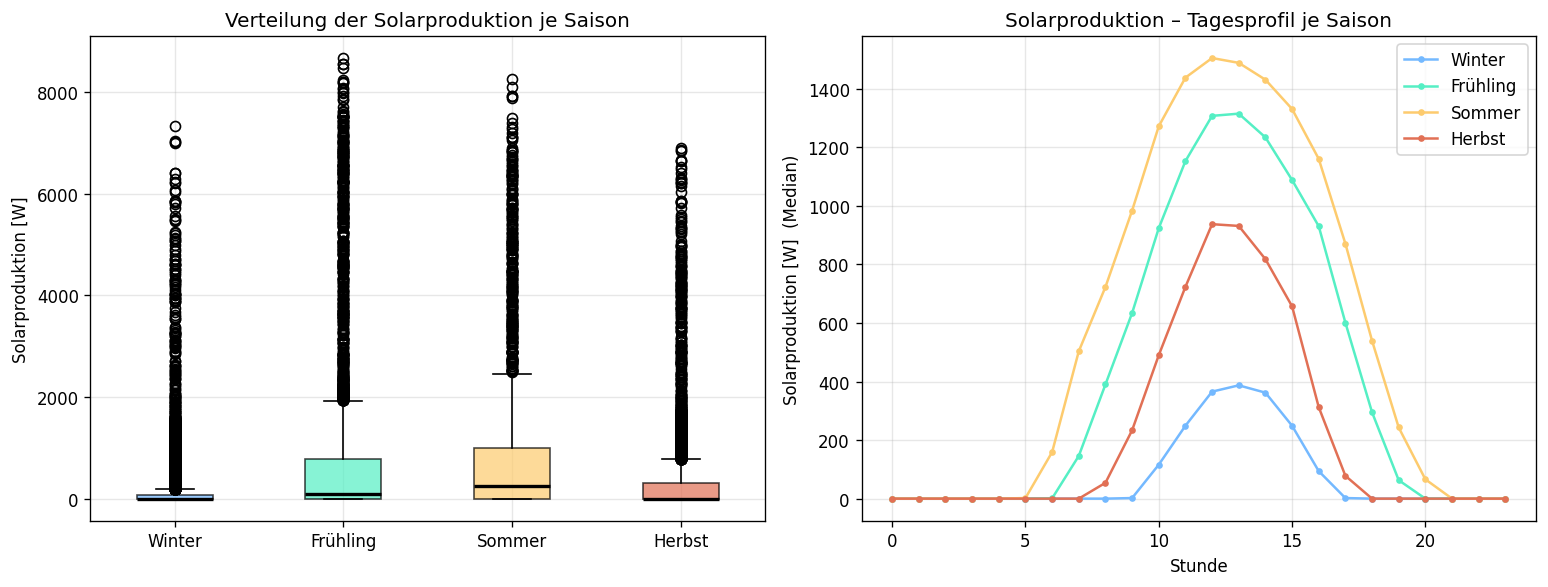

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Boxplot je Saison
data_by_season = [df[df["season"] == s][TARGET].dropna() for s in season_order]
bp = axes[0].boxplot(
    data_by_season,
    labels=season_order,
    patch_artist=True,
    medianprops={"color": "black", "linewidth": 2},
)
for patch, season in zip(bp["boxes"], season_order):
    patch.set_facecolor(season_colors[season])
    patch.set_alpha(0.7)

axes[0].set_ylabel("Solarproduktion [W]")
axes[0].set_title("Verteilung der Solarproduktion je Saison")

# Tagesprofil je Saison (Median)
for season in season_order:
    profile = (
        df[df["season"] == season]
        .groupby("hour")[TARGET]
        .median()
    )
    axes[1].plot(
        profile.index,
        profile.values,
        marker="o",
        markersize=3,
        label=season,
        color=season_colors[season],
    )

axes[1].set_xlabel("Stunde")
axes[1].set_ylabel("Solarproduktion [W]  (Median)")
axes[1].set_title("Solarproduktion – Tagesprofil je Saison")
axes[1].legend()

plt.tight_layout()
plt.show()


C:\Users\Annika\AppData\Local\Temp\ipykernel_20408\2867811194.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes.boxplot(


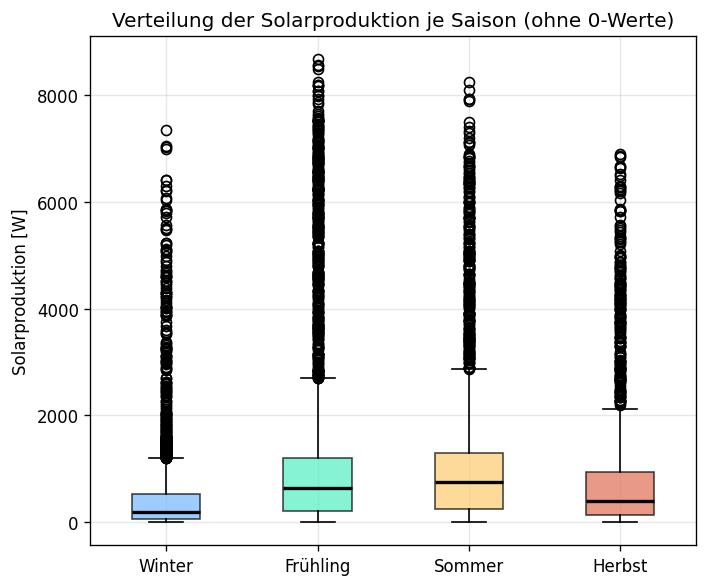

In [6]:
fig, axes = plt.subplots(1, 1, figsize=(6, 5))

# Boxplot je Saison (ohne 0-Werte)
data_by_season = [
    df[(df["season"] == s) & (df[TARGET] > 0)][TARGET].dropna()
    for s in season_order
]

bp = axes.boxplot(
    data_by_season,
    labels=season_order,
    patch_artist=True,
    medianprops={"color": "black", "linewidth": 2},
)

for patch, season in zip(bp["boxes"], season_order):
    patch.set_facecolor(season_colors[season])
    patch.set_alpha(0.7)

axes.set_ylabel("Solarproduktion [W]")
axes.set_title("Verteilung der Solarproduktion je Saison (ohne 0-Werte)")

plt.tight_layout()
plt.show()

## 4) Beispielwoche: Solarproduktion & Hausverbrauch

`Hausverbrauch` ist nicht Teil des vorberechneten Feature-Datensatzes und wird daher einmalig direkt aus den Rohdaten geladen.

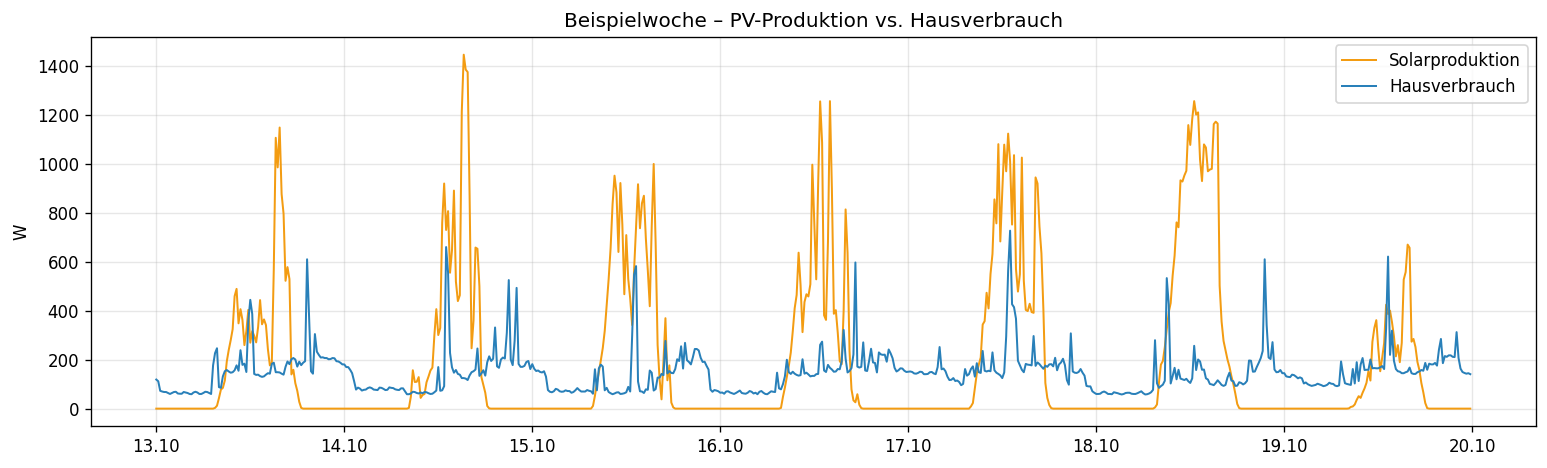

In [7]:
df_pv = load_pv_data()

# Mittlere Woche des Datensatzes wahlen
start = df_pv["timestamp"].iloc[len(df_pv) // 2].floor("D")
mask  = (df_pv["timestamp"] >= start) & (df_pv["timestamp"] < start + pd.Timedelta(days=7))
week  = df_pv[mask].set_index("timestamp")

fig, ax = plt.subplots(figsize=(13, 4))

ax.plot(week.index, week["Solarproduktion"], color="#f39c12", linewidth=1.2, label="Solarproduktion")
ax.plot(week.index, week["Hausverbrauch"],   color="#2980b9", linewidth=1.2, label="Hausverbrauch")

ax.set_ylabel("W")
ax.set_title("Beispielwoche – PV-Produktion vs. Hausverbrauch")
ax.legend()

ax.xaxis.set_major_formatter(mdates.DateFormatter("%d.%m"))
ax.xaxis.set_major_locator(mdates.DayLocator())

plt.tight_layout()
plt.show()


## 5) Autokorrelationsanalyse (ACF/PACF): Lag-Auswahl begründen 

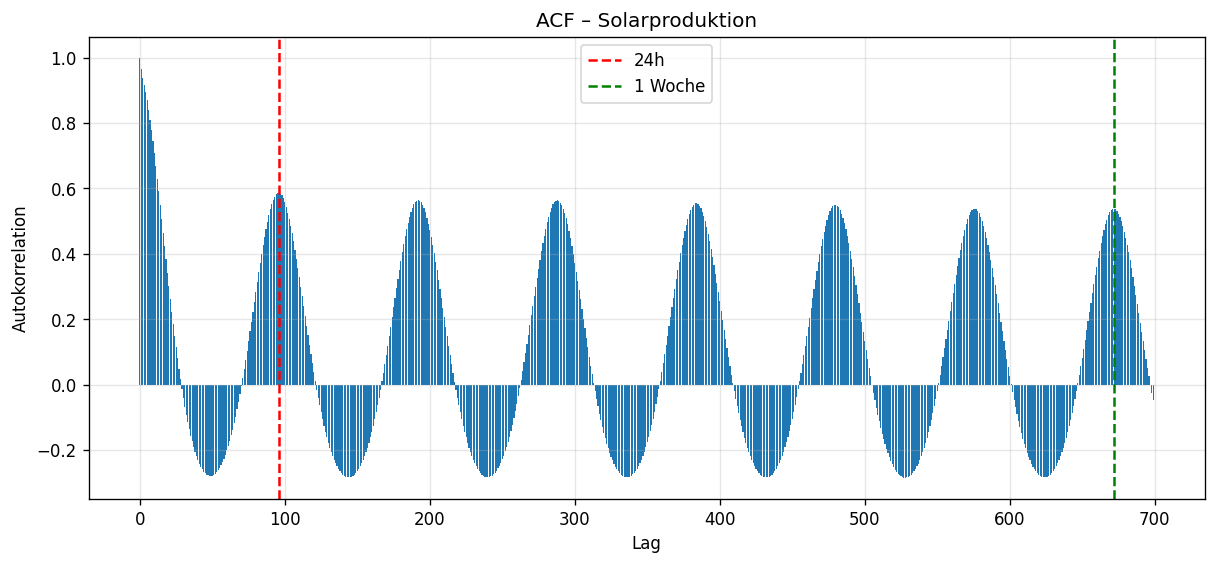

In [8]:
series = df[TARGET].dropna()

acf_values = [series.autocorr(lag=i) for i in range(700)]

plt.figure(figsize=(12,5))
plt.bar(range(700), acf_values)

plt.axvline(96, color="red", linestyle="--", label="24h")
plt.axvline(672, color="green", linestyle="--", label="1 Woche")

plt.xlabel("Lag")
plt.ylabel("Autokorrelation")
plt.title("ACF – Solarproduktion")

plt.legend()
plt.show()

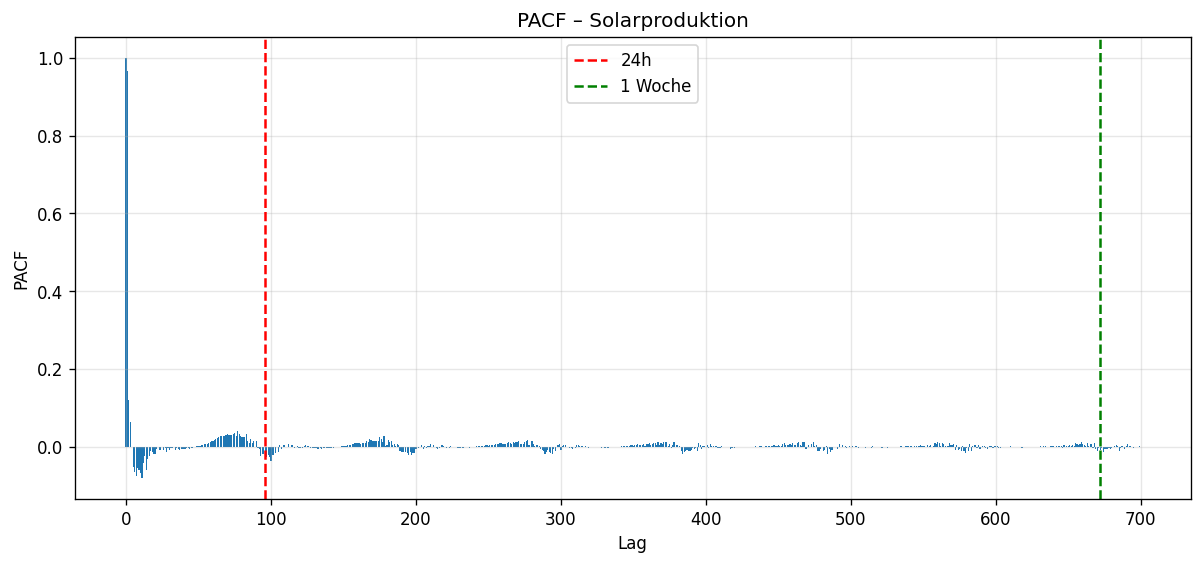

In [9]:
import numpy as np

def pacf_from_acf(acf_values, nlags):
    pacf = np.zeros(nlags)
    pacf[0] = 1
    
    phi = np.zeros((nlags, nlags))
    phi[1,1] = acf_values[1]
    pacf[1] = acf_values[1]

    for k in range(2, nlags):
        num = acf_values[k] - sum(phi[k-1,j]*acf_values[k-j] for j in range(1,k))
        den = 1 - sum(phi[k-1,j]*acf_values[j] for j in range(1,k))
        
        phi[k,k] = num / den
        
        for j in range(1,k):
            phi[k,j] = phi[k-1,j] - phi[k,k]*phi[k-1,k-j]
            
        pacf[k] = phi[k,k]
        
    return pacf

pacf_values = pacf_from_acf(acf_values, 700)

plt.figure(figsize=(12,5))
plt.bar(range(700), pacf_values)

plt.axvline(96, color="red", linestyle="--", label="24h")
plt.axvline(672, color="green", linestyle="--", label="1 Woche")

plt.xlabel("Lag")
plt.ylabel("PACF")
plt.title("PACF – Solarproduktion")

plt.legend()
plt.show()

## 6) Korrelationsmatrix: Solarproduktion ↔ GHI, Temperatur, Bewölkung

                 Solarproduktion  ghi_cloudy_sky  temperature_2m  \
Solarproduktion             1.00            0.68            0.42   
ghi_cloudy_sky              0.68            1.00            0.58   
temperature_2m              0.42            0.58            1.00   
cloud_cover_low            -0.14           -0.14           -0.34   

                 cloud_cover_low  
Solarproduktion            -0.14  
ghi_cloudy_sky             -0.14  
temperature_2m             -0.34  
cloud_cover_low             1.00  


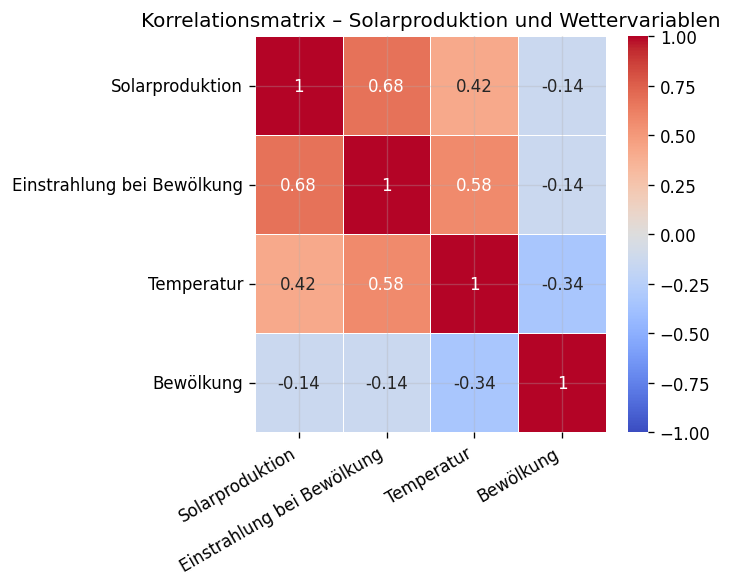

In [10]:
# Mapping für Anzeige-Namen (nur für Visualisierung)
label_map = {
    "Solarproduktion": "Solarproduktion",
    "temperature_2m": "Temperatur",
    "cloud_cover_low": "Bewölkung",
    "ghi_cloudy_sky": "Einstrahlung bei Bewölkung"
}

vars_for_corr = [
    TARGET,
    "ghi_cloudy_sky",
    "temperature_2m",
    "cloud_cover_low"
]

corr_matrix = df[vars_for_corr].corr()

print(corr_matrix.round(2))

# 👉 Kopie für Anzeige umbenennen
corr_display = corr_matrix.rename(
    index=label_map,
    columns=label_map
)

plt.figure(figsize=(6,5))

sns.heatmap(
    corr_display,
    annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    linewidths=0.5
)

plt.title("Korrelationsmatrix – Solarproduktion und Wettervariablen")
plt.xticks(rotation=30, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

## 7) KDE-Dichteplot Solarproduktion: bimodale Verteilung (0 / >0) sichtbar machen


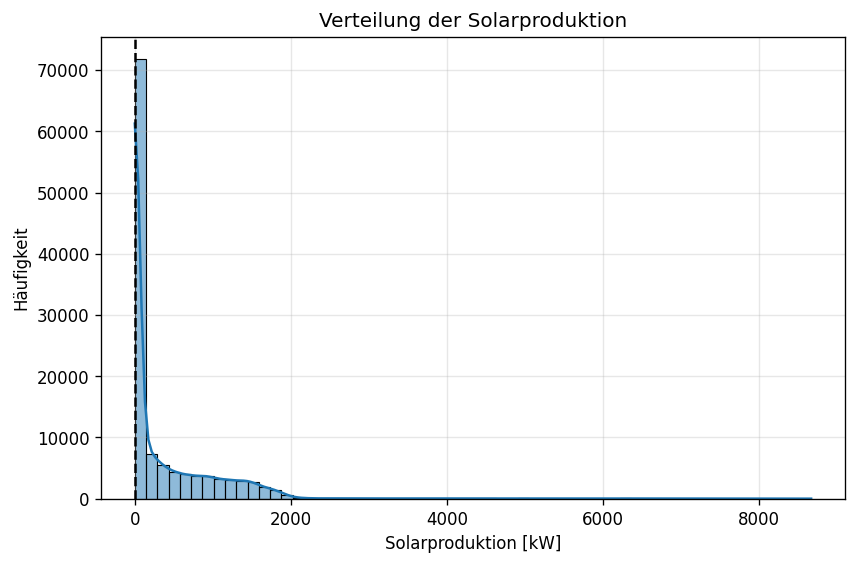

In [11]:
plt.figure(figsize=(8,5))

sns.histplot(
    df[TARGET],
    bins=60,
    kde=True
)

plt.xlabel("Solarproduktion [kW]")
plt.ylabel("Häufigkeit")
plt.title("Verteilung der Solarproduktion")

plt.axvline(0, color="black", linestyle="--")

plt.show()

C:\Users\Annika\AppData\Local\Temp\ipykernel_20408\285346897.py:7: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(night, fill=True, label="Nacht (PV = 0)")


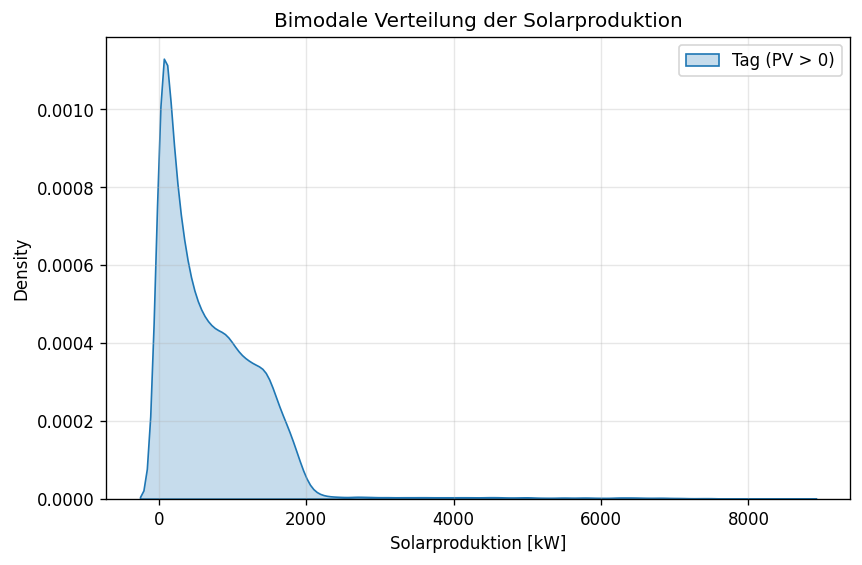

In [12]:
night = df[df[TARGET] == 0][TARGET]
day   = df[df[TARGET] > 0][TARGET]

plt.figure(figsize=(8,5))

sns.kdeplot(day, fill=True, label="Tag (PV > 0)")
sns.kdeplot(night, fill=True, label="Nacht (PV = 0)")

plt.xlabel("Solarproduktion [kW]")
plt.title("Bimodale Verteilung der Solarproduktion")

plt.legend()
plt.show()

## 5) Offene Punkte (TODO)


- **zu 3.2)** Warum hat Frühling höhere Spitzen als Sommer? (vermutlich wegen der Sache, dass bei hohen Temperaturen der Wirkungsgrad sinkt). 
- **maximum stunde im average / median** wann genau ist bei unserer anlage (jeweils fuer sommer/winterzeit) das maximum im tagesverlauf und deckt sich das mit der literatur.